In [19]:
# CORRELATION BETWEEN CLINICAL AND IMAGE FEATURES -> SPEARMAN TEST
from helper_files.feature_selection_helper import *


clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
numeric_features_clinical = clinical_df.select_dtypes(include=['number']).columns

all_csvs = merged_lesions_csv(r"E:\DATA_Myelomy")
for name, radiomic_df in all_csvs.items():
    print(f"Processing: {name}")

    merged_df = pd.merge(radiomic_df, clinical_df, left_on='patient', right_on='Patient ID')

    if merged_df.empty:
        print(f"Skipping {name}: No matching patients found.")
        continue

    numeric_features_image = radiomic_df.select_dtypes(include=['number']).columns

    for clinical_col in numeric_features_clinical:

        if clinical_col not in merged_df.columns:
            continue

        spearman_corr = {}
        for radiomic_col in numeric_features_image:

            data_subset = merged_df[[radiomic_col, clinical_col]].dropna()

            if len(data_subset) > 1: # Spearman needs at least 2 points
                corr, p_value = spearmanr(data_subset[radiomic_col], data_subset[clinical_col], nan_policy='omit')

                if p_value < 0.05:
                    spearman_corr[radiomic_col] = {'corr': corr, 'p_value': p_value}

        if spearman_corr:
            spearman_df = pd.DataFrame(spearman_corr).T
            spearman_df = spearman_df.sort_values(by='corr', ascending=False)
            print(f"Results for {clinical_col}:")
            print(spearman_df.head(3))
            print(spearman_df.tail(3))
        else:
            print(f"No significant correlations for {clinical_col}")
        print("-" * 50)

Processing: BMD
Results for Serum M-protein quantity (g/l):
                                                     corr   p_value
gradient_glrlm_GrayLevelNonUniformityNormalized  0.358793  0.004876
gradient_glrlm_LowGrayLevelRunEmphasis           0.319706  0.012772
gradient_firstorder_Kurtosis                     0.299008  0.020300
                                                  corr   p_value
gradient_glrlm_GrayLevelVariance             -0.333171  0.009289
gradient_glrlm_ShortRunHighGrayLevelEmphasis -0.350281  0.006075
gradient_glrlm_HighGrayLevelRunEmphasis      -0.351978  0.005817
--------------------------------------------------
Results for Serum kappa FLC quantity (mg/l:
                       corr  p_value
gradient_glcm_MCC  0.288916  0.02276
                       corr  p_value
gradient_glcm_MCC  0.288916  0.02276
--------------------------------------------------
Results for Serum lambda FLC quantity (mg/l):
                                                    corr   p_value
o

Analyzing BMD...


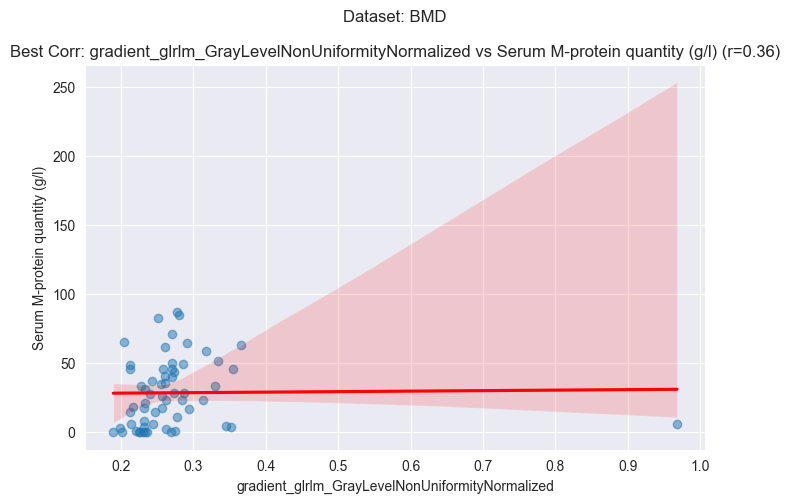

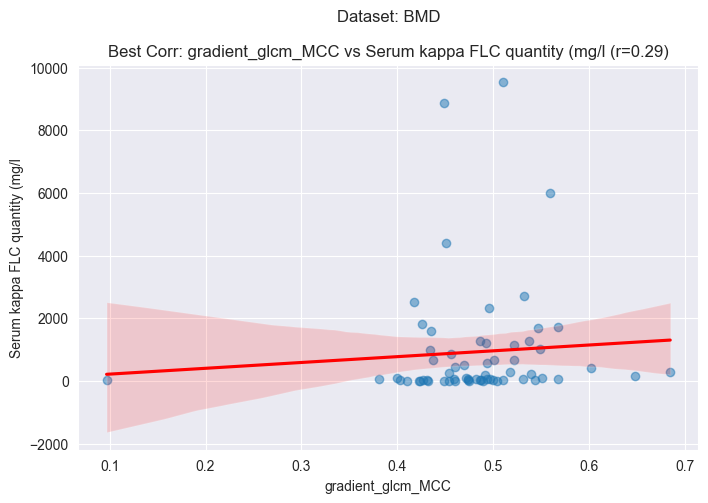

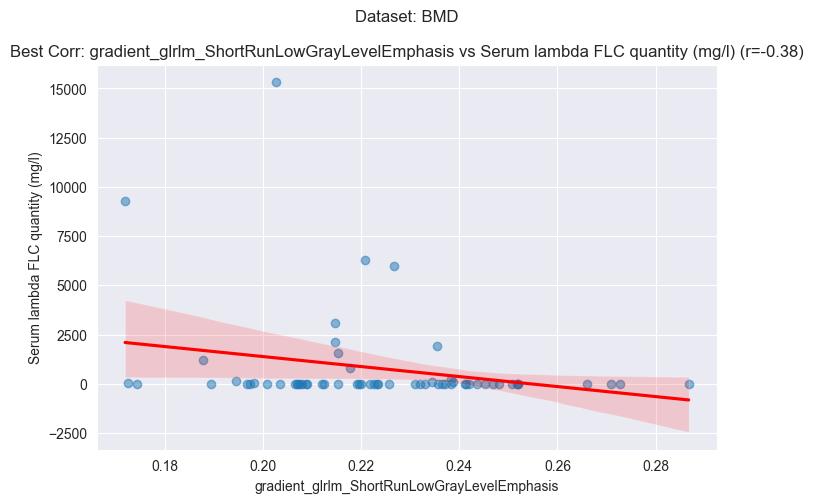

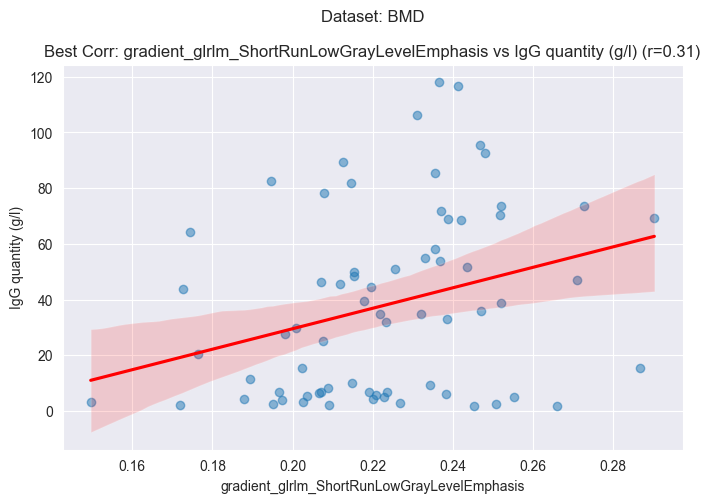

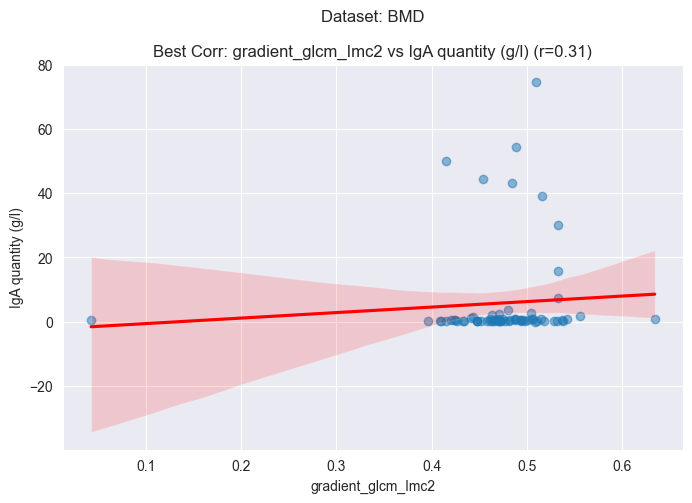

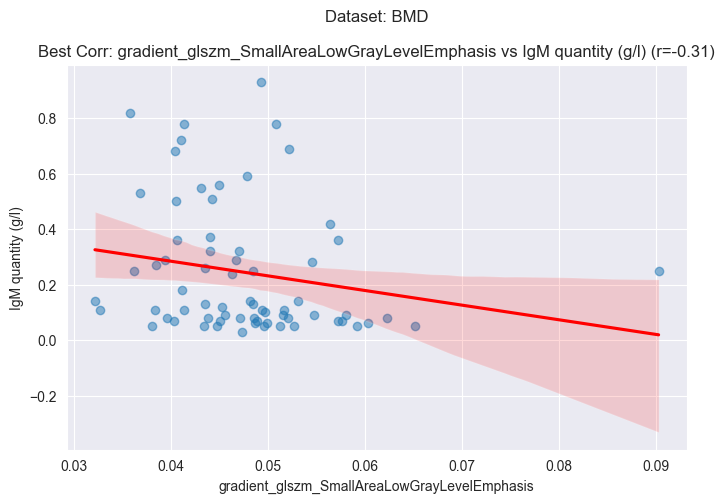

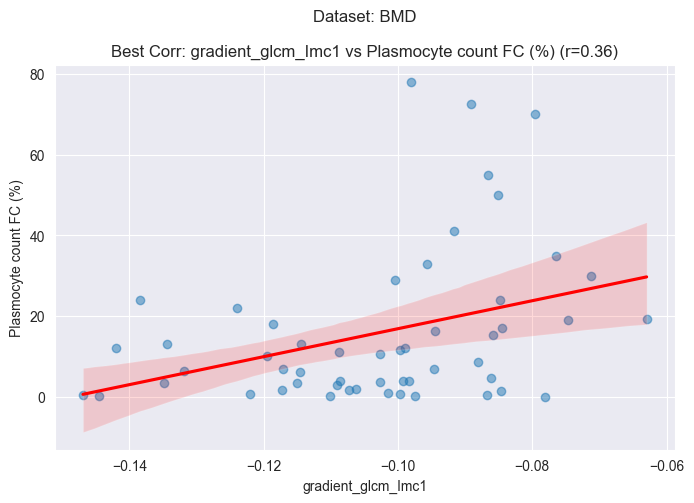

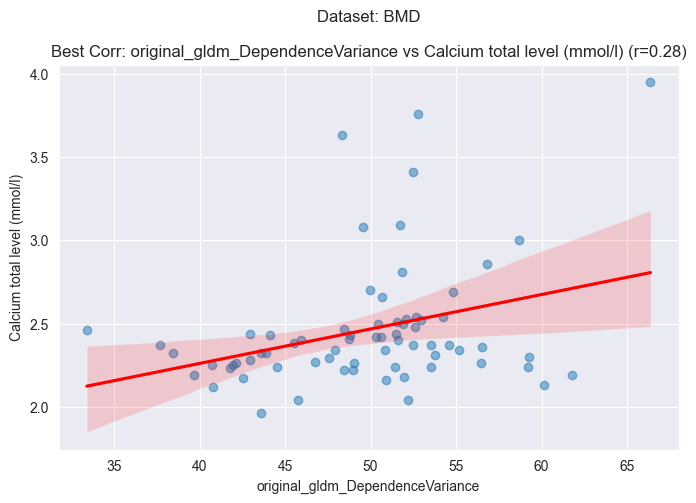

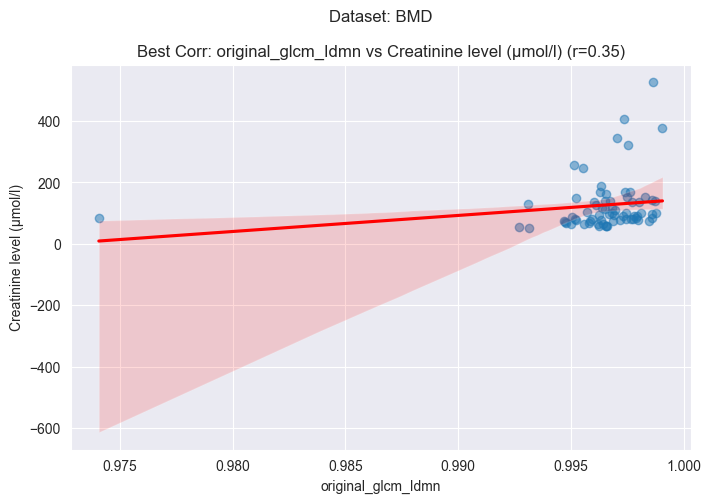

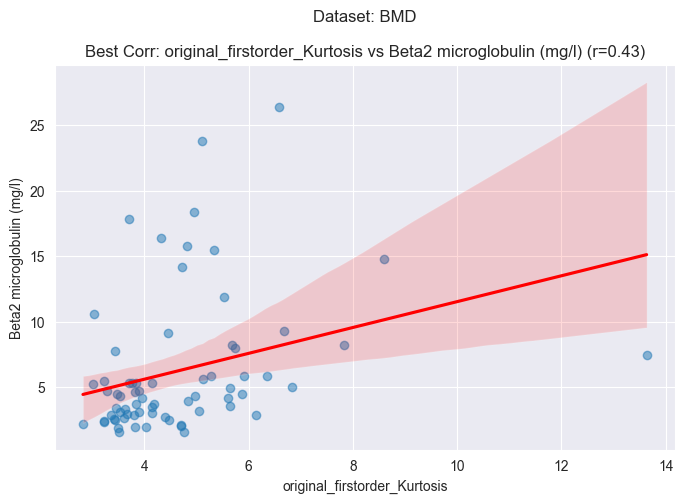


Analyzing CaSupp_25...


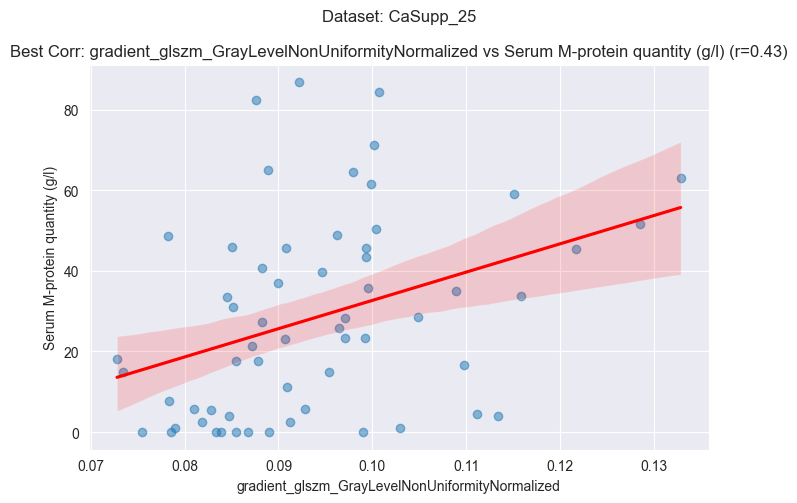

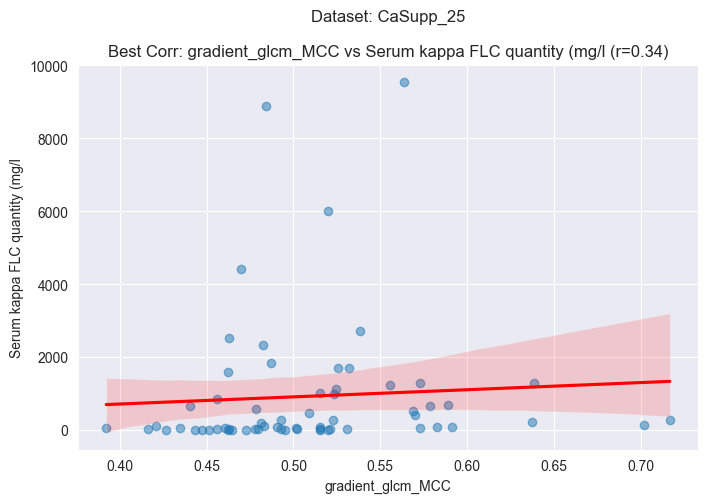

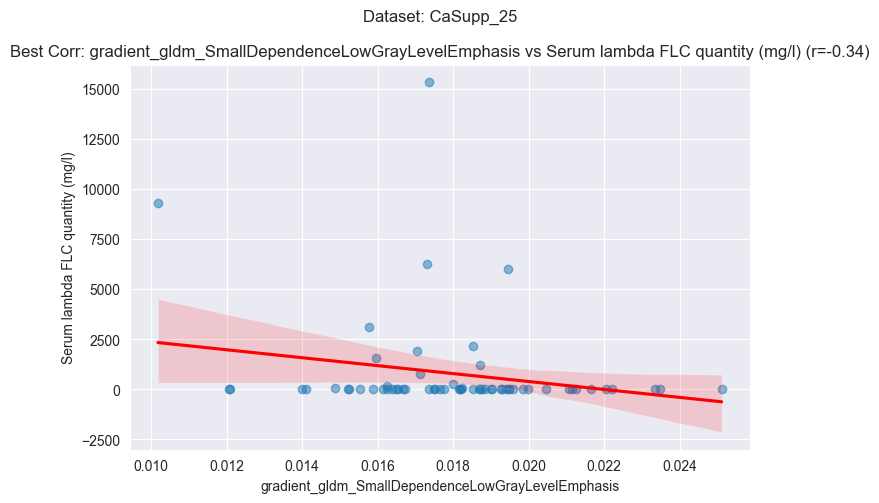

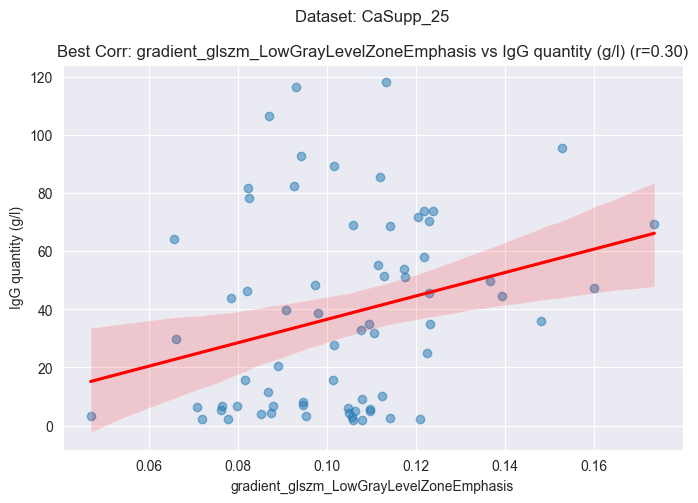

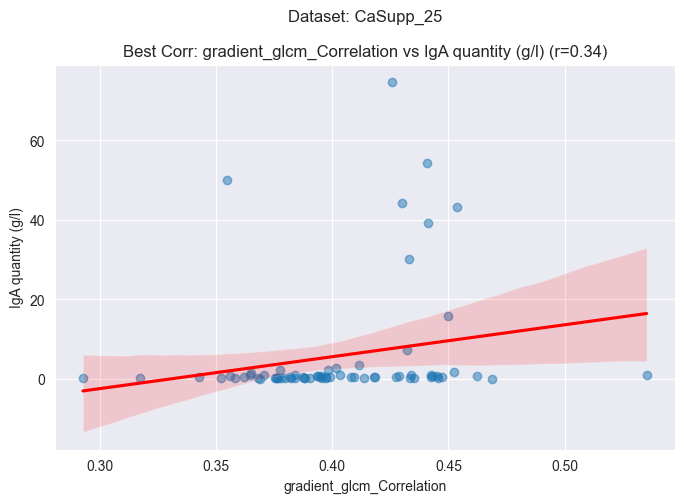

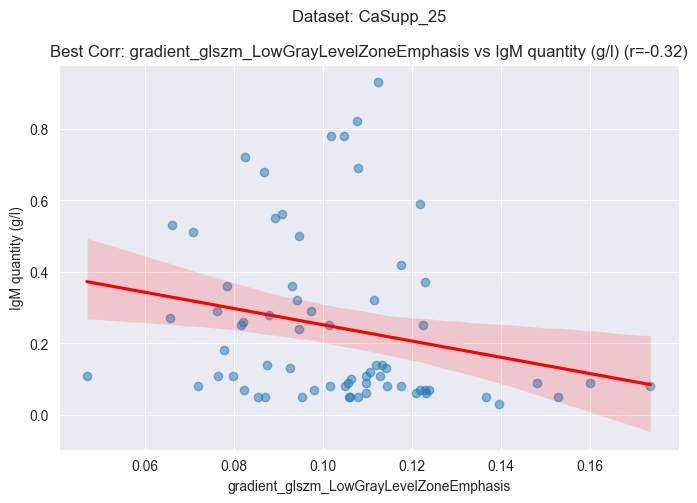

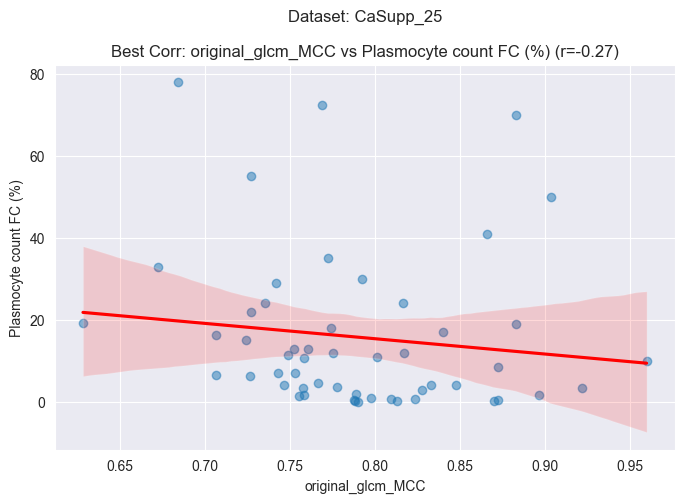

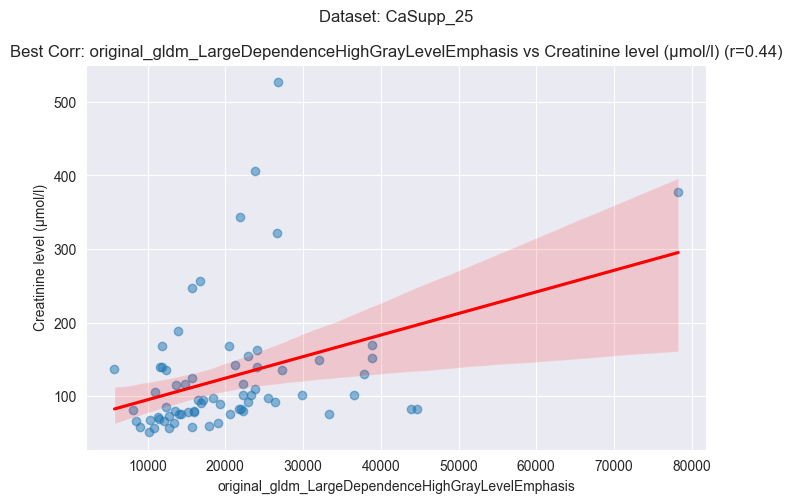

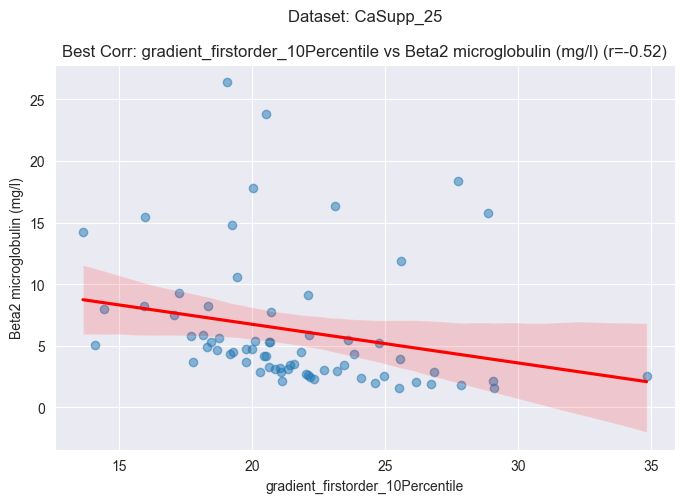


Analyzing konv...


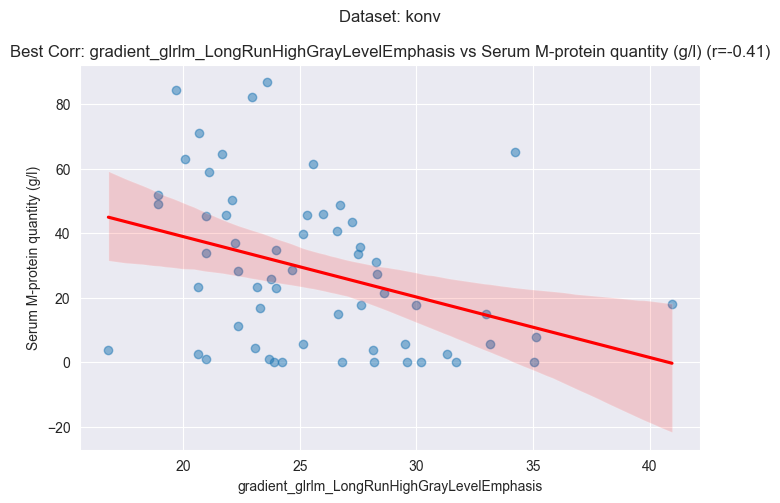

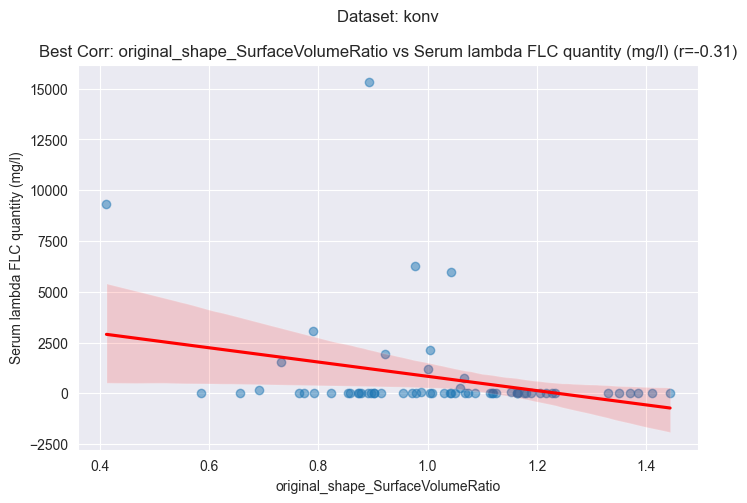

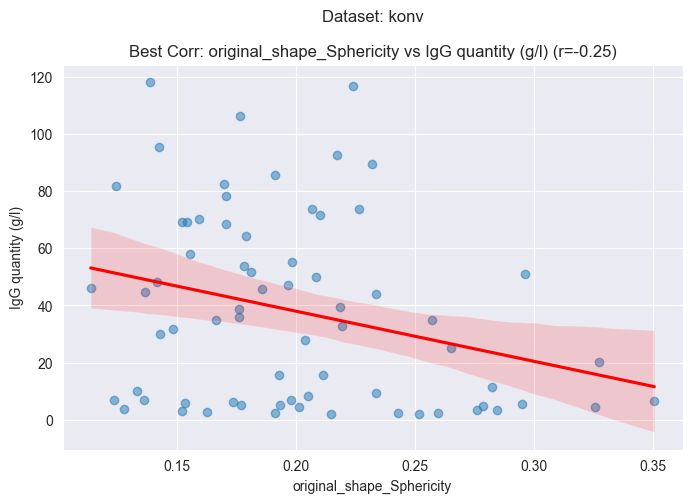

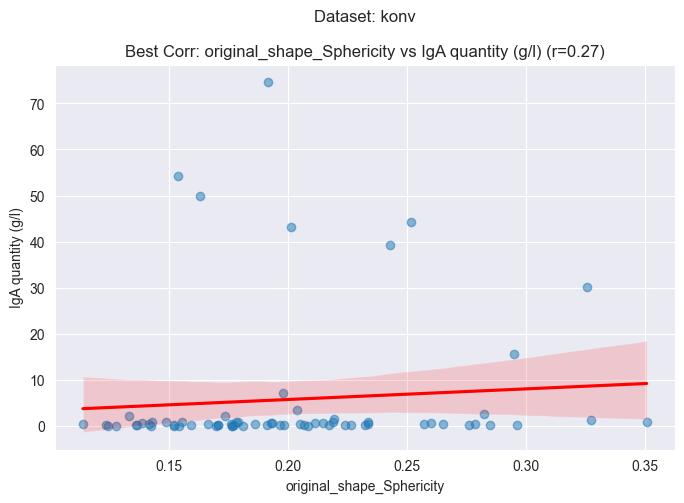

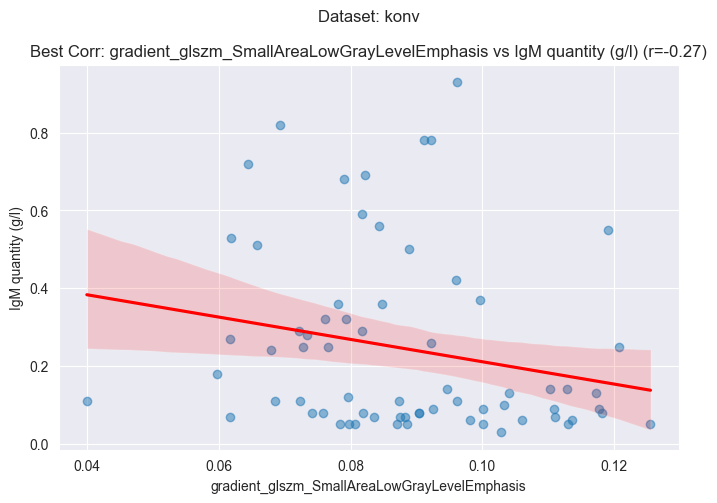

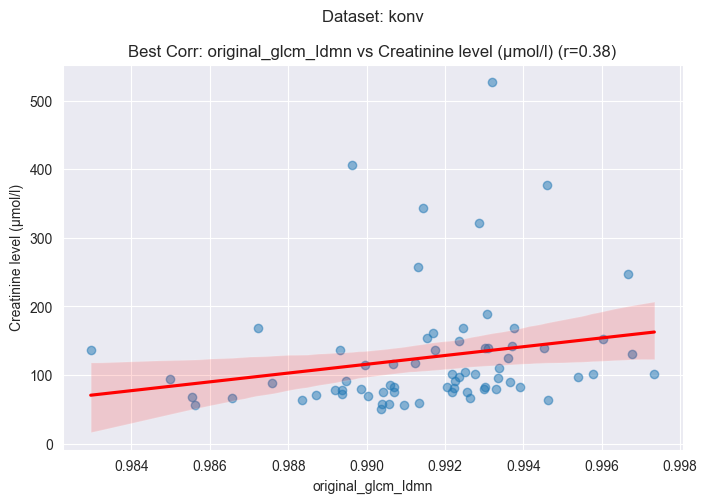

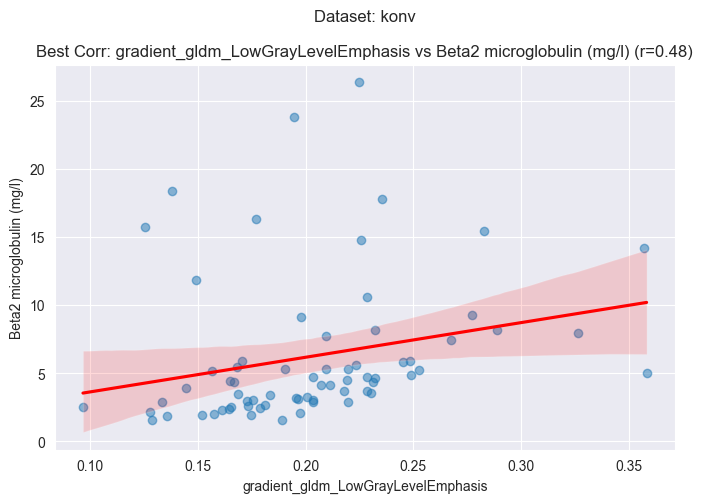


Analyzing monoe_120kev...


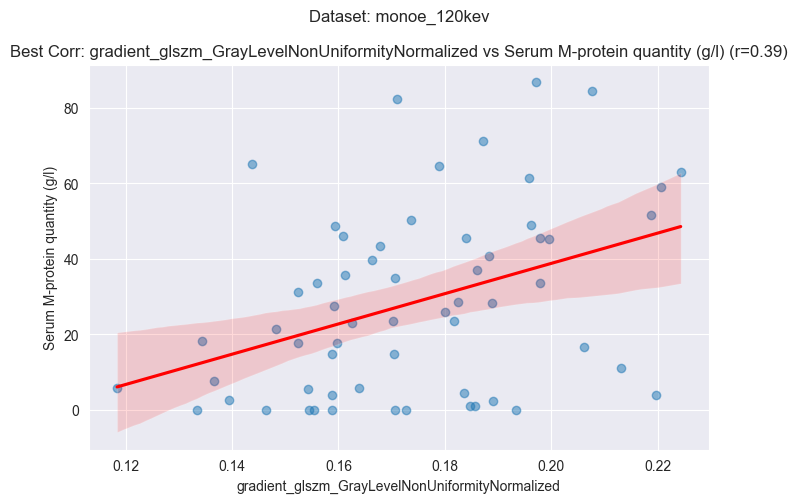

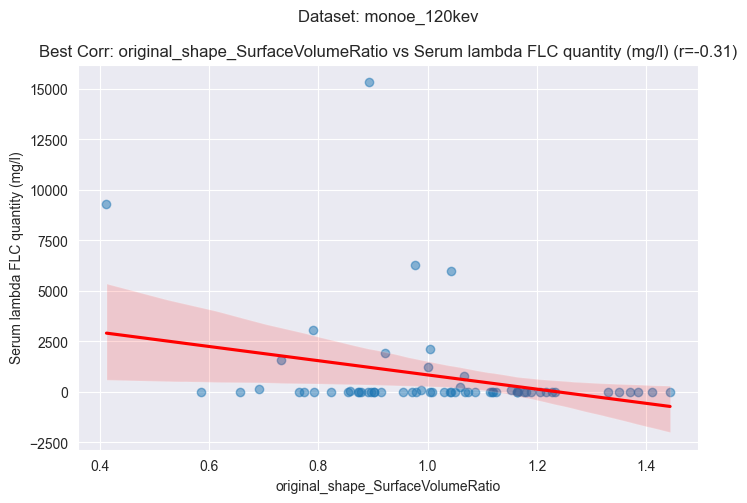

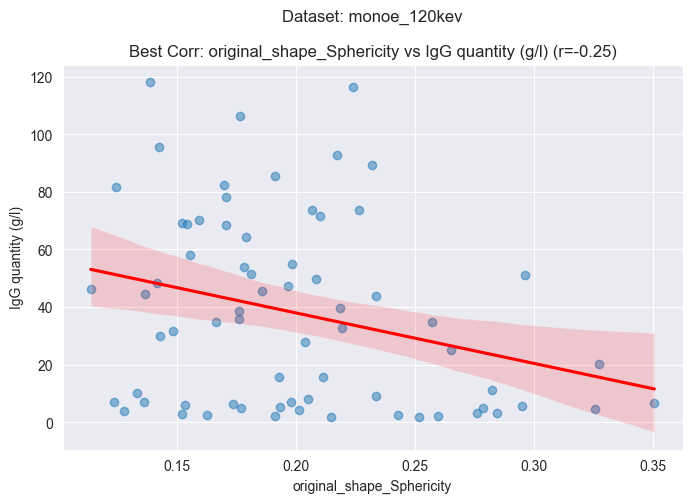

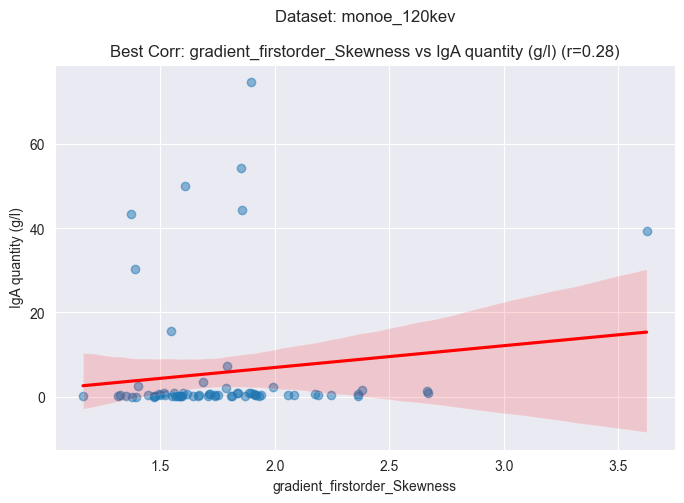

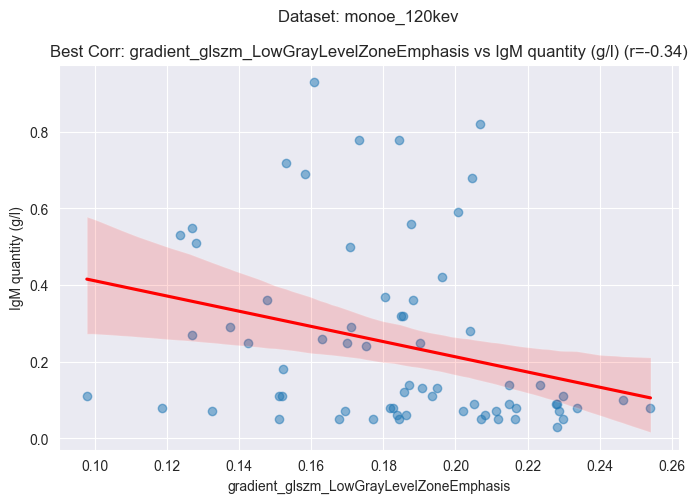

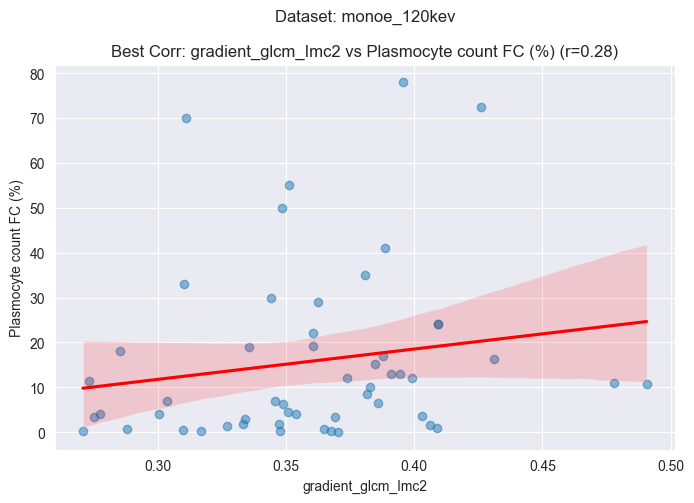

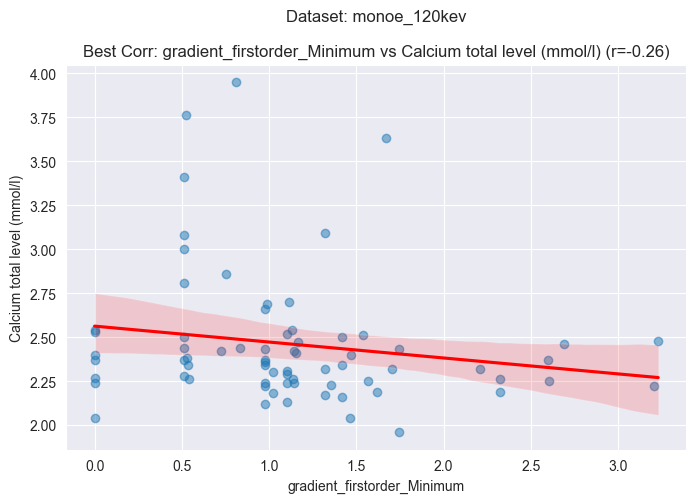

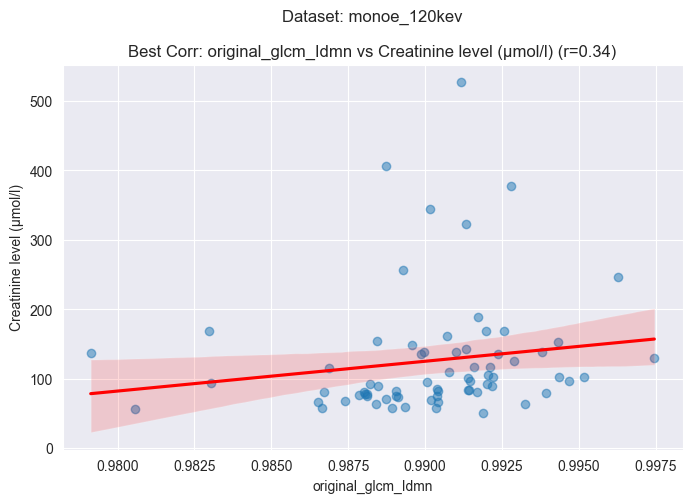

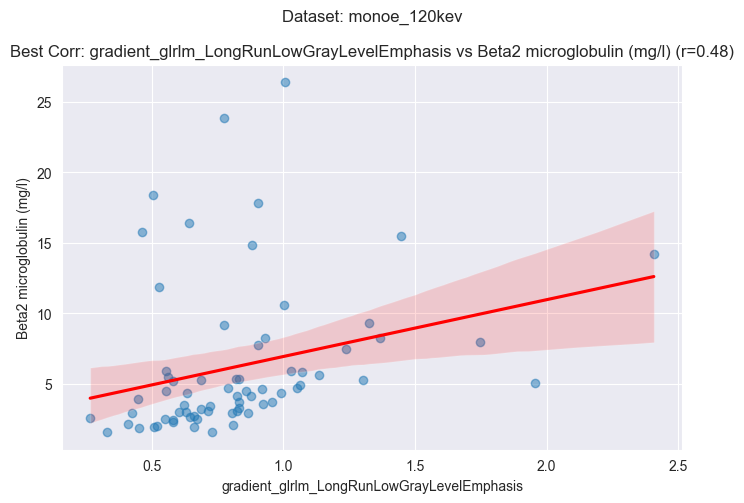


Analyzing monoe_40kev...


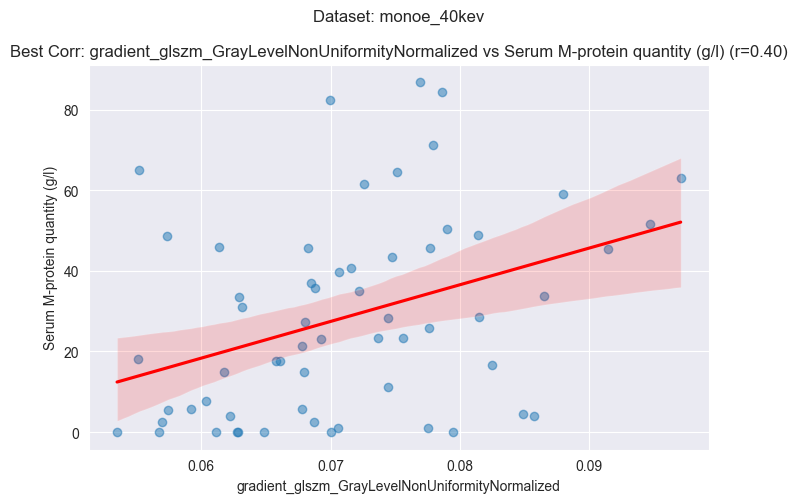

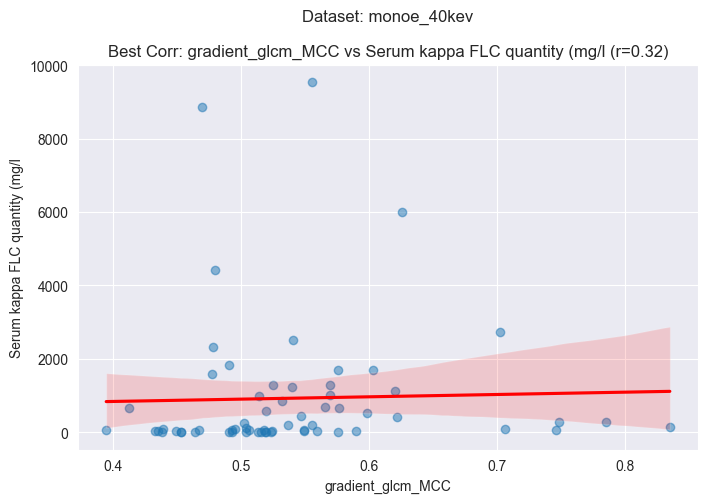

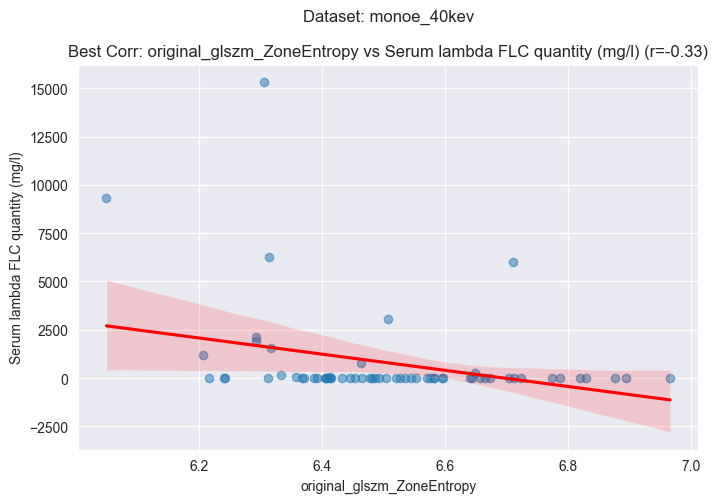

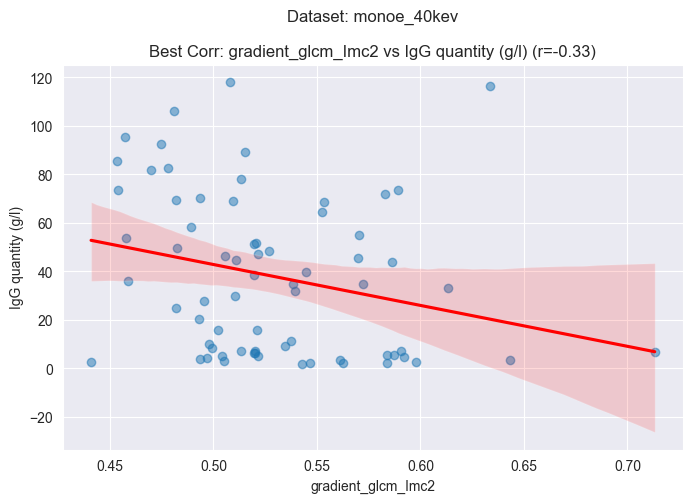

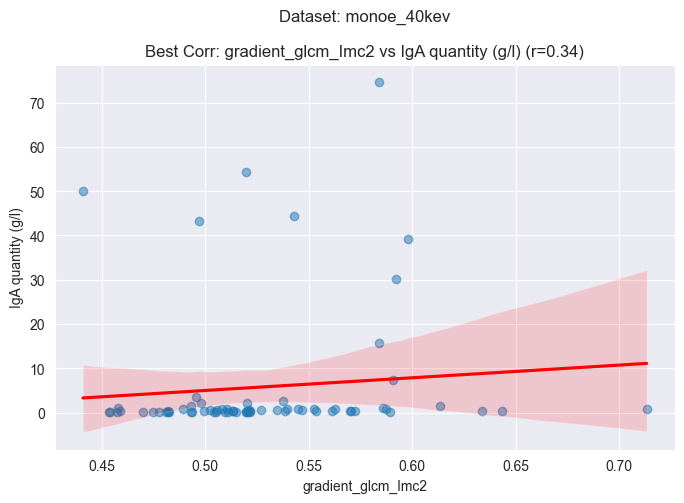

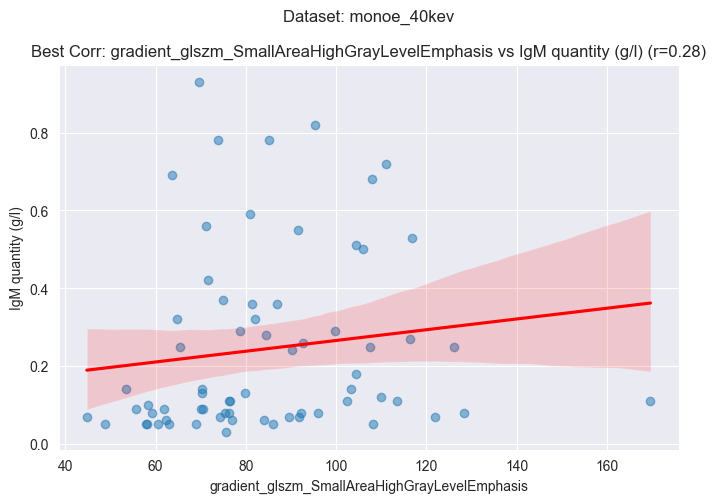

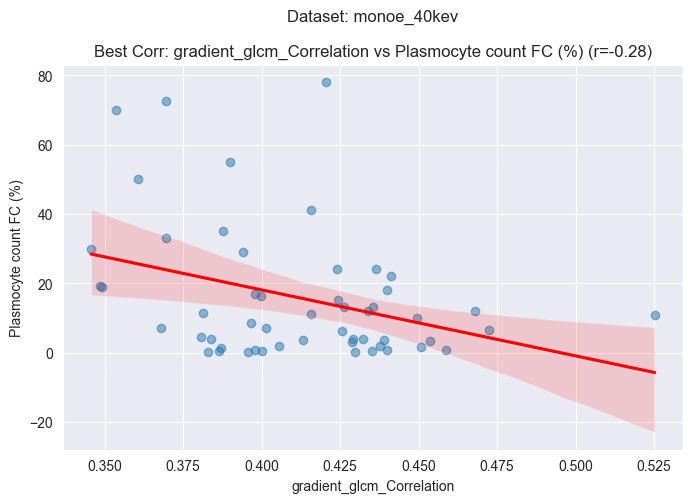

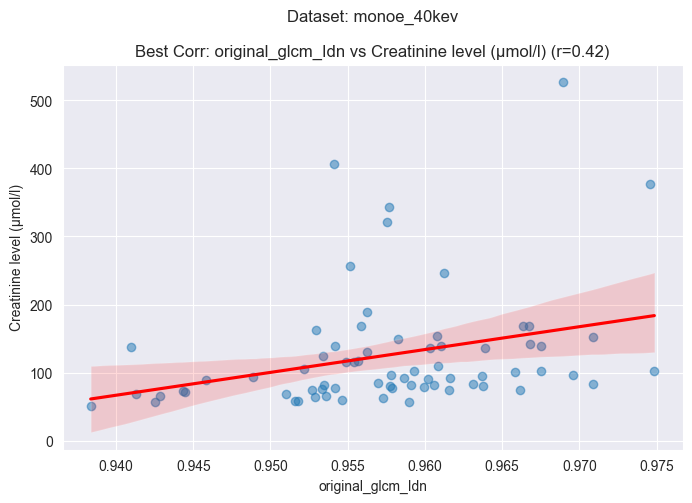

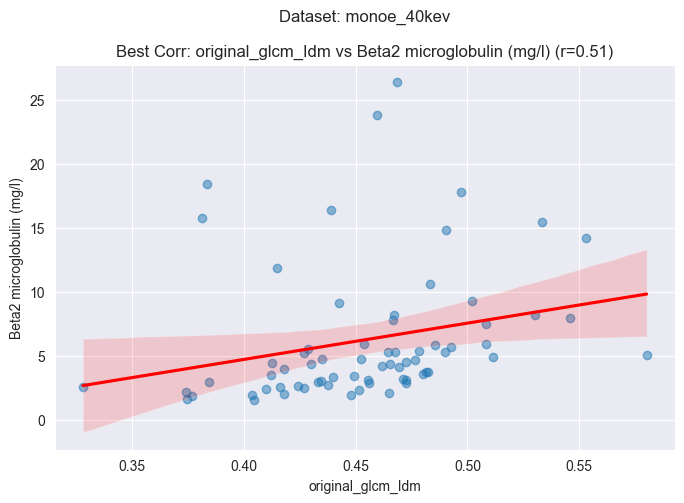


Analyzing monoe_80kev...


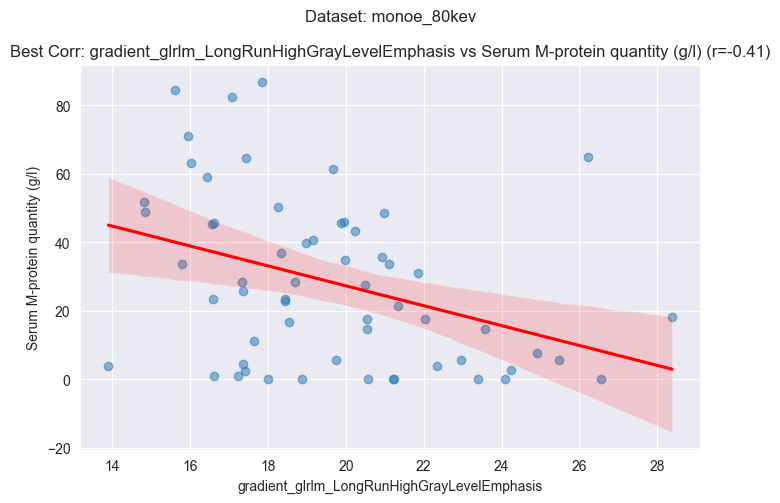

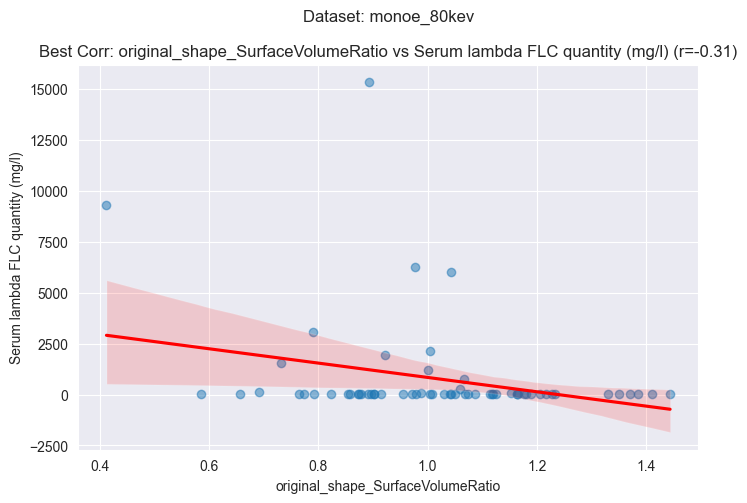

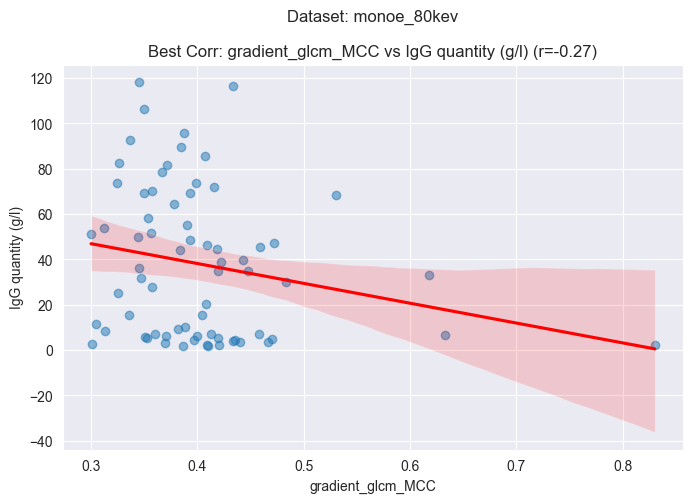

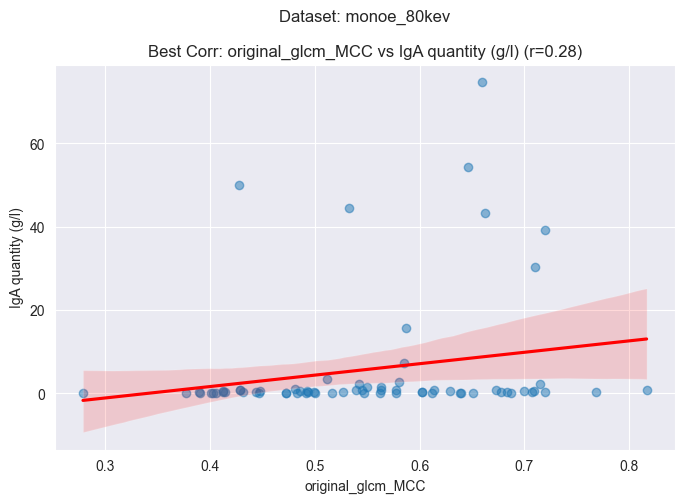

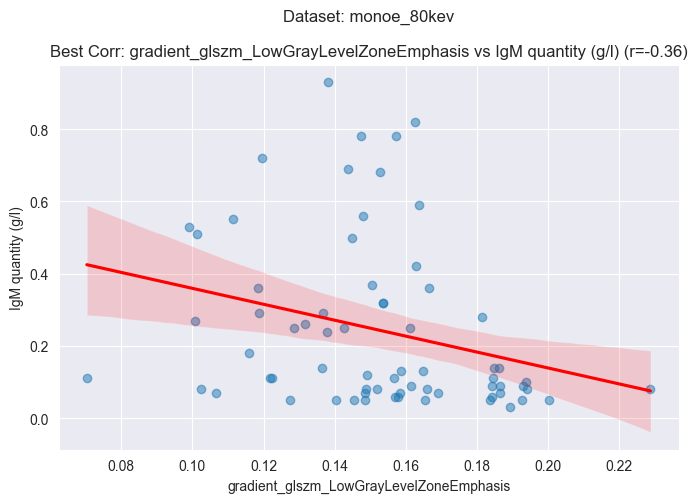

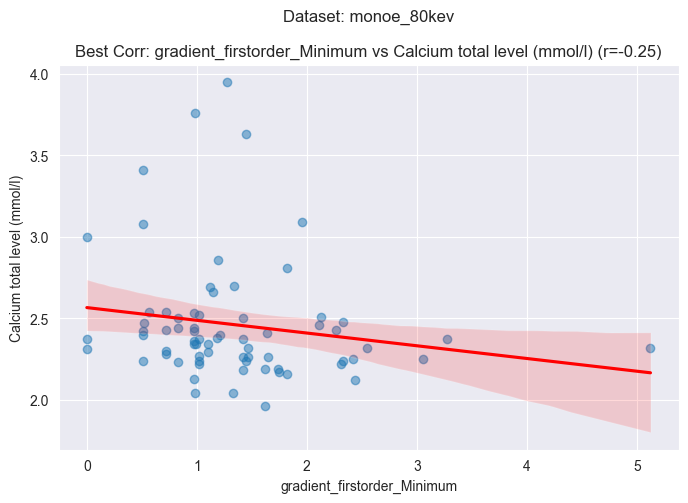

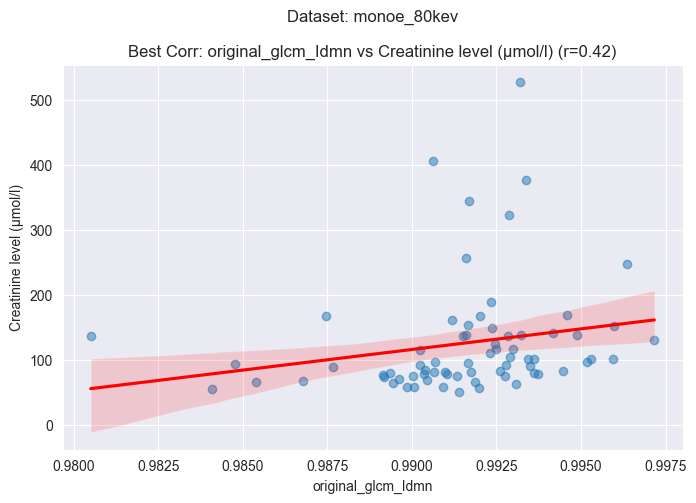

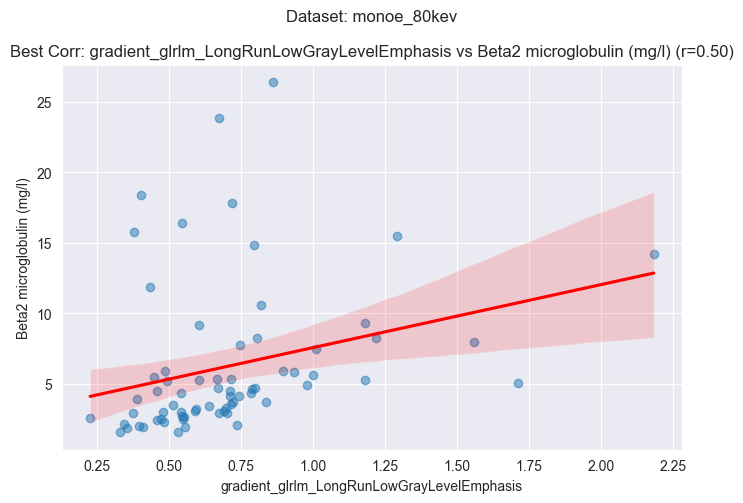

In [18]:
for name, radiomic_df in all_csvs.items():
    print(f"Analyzing {name}...")

    merged_df = pd.merge(radiomic_df, clinical_df, left_on='patient', right_on='Patient ID')

    if merged_df.empty:
        continue

    numeric_features_image = radiomic_df.select_dtypes(include=['number']).columns

    for clinical_col in numeric_features_clinical:
        if clinical_col not in merged_df.columns:
            continue

        best_radiomic = None
        max_abs_corr = 0
        final_corr_val = 0

        for radiomic_col in numeric_features_image:
            subset = merged_df[[radiomic_col, clinical_col]].dropna()

            if len(subset) > 1:
                corr, p_value = spearmanr(subset[radiomic_col], subset[clinical_col], nan_policy='omit')

                if p_value < 0.05 and abs(corr) > max_abs_corr:
                    max_abs_corr = abs(corr)
                    final_corr_val = corr
                    best_radiomic = radiomic_col

        # 2. Plotting the champion
        if best_radiomic:
            plt.figure(figsize=(8, 5))
            sns.regplot(data=merged_df, x=best_radiomic, y=clinical_col,
                        scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})

            plt.title(f"Dataset: {name}\n\nBest Corr: {best_radiomic} vs {clinical_col} (r={final_corr_val:.2f})")
            plt.xlabel(best_radiomic)
            plt.ylabel(clinical_col)
            plt.show()
            print()

In [ ]:
plt.style.use('default')

for name, radiomic_df in all_csvs.items():
    print(f"Analyzing {name}...")

    merged_df = pd.merge(radiomic_df, clinical_df, left_on='patient', right_on='Patient ID')

    if merged_df.empty:
        continue

    numeric_features_image = radiomic_df.select_dtypes(include=['number']).columns

    for clinical_col in numeric_features_clinical:
        if clinical_col not in merged_df.columns:
            continue

        best_radiomic = None
        max_abs_corr = 0
        final_corr_val = 0

        for radiomic_col in numeric_features_image:
            subset = merged_df[[radiomic_col, clinical_col]].dropna()

            if len(subset) > 1:
                corr, p_value = spearmanr(subset[radiomic_col], subset[clinical_col], nan_policy='omit')

                if p_value < 0.05 and abs(corr) > max_abs_corr:
                    max_abs_corr = abs(corr)
                    final_corr_val = corr
                    best_radiomic = radiomic_col

        # 2. Plotting the champion
        if best_radiomic:
            plt.figure(figsize=(8, 5))
            sns.regplot(data=merged_df, x=best_radiomic, y=clinical_col,
                        scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})

            plt.title(f"Dataset: {name}\n\nBest Corr: {best_radiomic} vs {clinical_col} (r={final_corr_val:.2f})")
            plt.xlabel(best_radiomic)
            plt.ylabel(clinical_col)
            plt.show()
            print()

In [24]:
# RELATION BETWEEN CLINICAL AND IMAGE FEATURES -> KRUSKAL-WALLIS TEST
from helper_files.feature_selection_helper import *


clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
categoric_features_clinical = ["ISS classification", "M-protein type", "Light chain type"]

all_csvs = merged_lesions_csv(r"E:\DATA_Myelomy")
for name, radiomic_df in all_csvs.items():
    print(f"Processing: {name}")

    merged_df = pd.merge(radiomic_df, clinical_df, left_on='patient', right_on='Patient ID')

    if merged_df.empty:
        print(f"Skipping {name}: No matching patients found.")
        continue

    numeric_features_image = radiomic_df.select_dtypes(include=['number']).columns

    for clinical_col in categoric_features_clinical:

        if clinical_col not in merged_df.columns:
            continue

        kruskal_wallis = {}
        for radiomic_col in numeric_features_image:

            data_subset = merged_df[[radiomic_col, clinical_col]].dropna()

            groups = [group[radiomic_col].dropna().values for name, group in merged_df.groupby(clinical_col)]

            if len(groups) > 1:
                stat, p_value = kruskal(*groups)

                if p_value < 0.05:
                    kruskal_wallis[radiomic_col] = {'stat': stat, 'p_value': p_value}

        if kruskal_wallis:
            kruskal_wallis_df = pd.DataFrame(kruskal_wallis).T
            kruskal_wallis_df = kruskal_wallis_df.sort_values(by='stat', ascending=False)
            print(f"Results for {clinical_col}:")
            print(kruskal_wallis_df.head(3))
        else:
            print(f"No significant correlations for {clinical_col}")
        print("-" * 50)

Processing: BMD
Results for ISS classification:
                                                      stat   p_value
original_firstorder_Kurtosis                     17.551540  0.000154
original_firstorder_InterquartileRange           15.972294  0.000340
original_firstorder_RobustMeanAbsoluteDeviation  13.753247  0.001032
--------------------------------------------------
Results for M-protein type:
                                                 stat   p_value
gradient_glrlm_ShortRunLowGrayLevelEmphasis  8.630025  0.013366
gradient_firstorder_Kurtosis                 6.585165  0.037158
--------------------------------------------------
Results for Light chain type:
                                                    stat   p_value
original_glszm_SmallAreaEmphasis                7.370151  0.025095
original_glszm_SizeZoneNonUniformityNormalized  7.085668  0.028931
original_shape_Elongation                       6.900208  0.031742
--------------------------------------------------
Proce

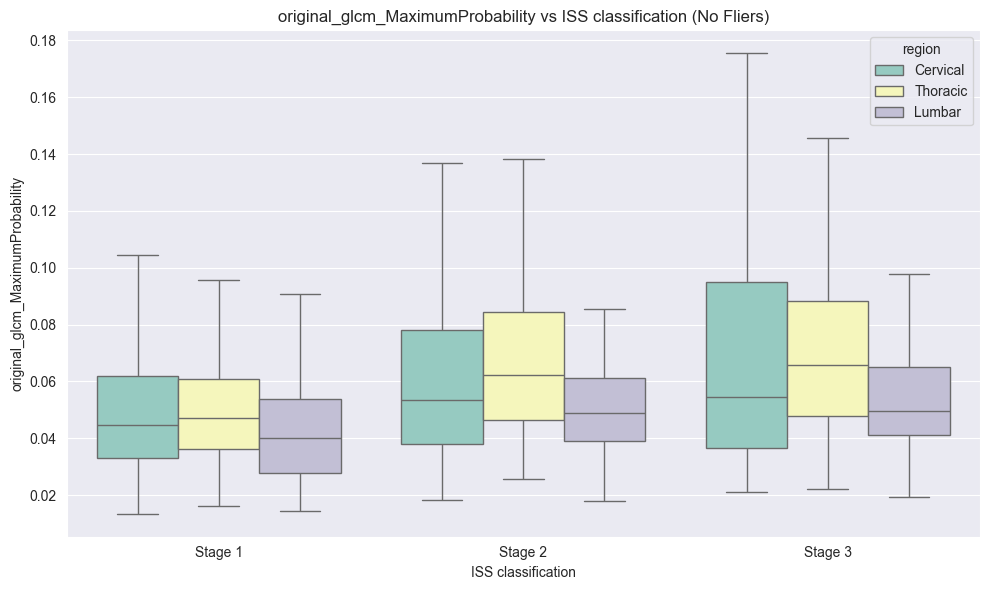


STATISTICAL ANALYSIS: Kruskal-Wallis Test

Region: Cervical
p-value: 0.0227
Significant (p < 0.05): YES

Region: Thoracic
p-value: 0.0000
Significant (p < 0.05): YES

Region: Lumbar
p-value: 0.0001
Significant (p < 0.05): YES


In [10]:
# RELATION BETWEEN CATEGORICAL VARIABLES SEPARATELY IN C/T/L VERTEBRAE -> KRUSKAL-WALLIS TEST
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# --- 1. Load and Clean Data ---
main_folder = r"E:\DATA_Myelomy"
lesion_data = []
vertebra_data = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)
    lesion_csv = os.path.join(folder_path, "monoe_40kev_radiomics_lesions_features.csv")

    if os.path.isfile(lesion_csv):
        df_l = pd.read_csv(lesion_csv)
        df_l["patient"] = folder_name
        lesion_data.append(df_l)

# Combine and merge
df = pd.concat(lesion_data, ignore_index=True)
df = df[df["vertebra_name"] != "S1"]

# Define regions
cervical = [f'C{i}' for i in range(1,8)]
thoracic = [f'T{i}' for i in range(1,13)]
lumbar = [f'L{i}' for i in range(1,6)]

def map_region(vertebra):
    if vertebra in cervical: return 'Cervical'
    elif vertebra in thoracic: return 'Thoracic'
    else: return 'Lumbar'

df['region'] = df['vertebra_name'].apply(map_region)

# Merge clinical data
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
df_final = pd.merge(df, clinical_df[['Patient ID', 'ISS classification']], left_on='patient', right_on='Patient ID')

img_feature = "original_glcm_MaximumProbability"  # gradient_firstorder_10Percentile

# Plot 2: No Fliers
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")
sns.boxplot(data=df_final, x="ISS classification", y=img_feature, hue="region", hue_order=["Cervical", "Thoracic", "Lumbar"], showfliers=False)
plt.title(f"{img_feature} vs ISS classification (No Fliers)")
plt.tight_layout()
plt.show()

# --- 3. Statistical Analysis: Kruskal-Wallis ---
print("\n" + "="*50)
print("STATISTICAL ANALYSIS: Kruskal-Wallis Test")
print("="*50)

regions = ["Cervical", "Thoracic", "Lumbar"]

for region in regions:
    subset = df_final[df_final['region'] == region].dropna()
    groups = [group[img_feature].values for name, group in subset.groupby('ISS classification')]

    if len(groups) > 1:
        stat, p_value = kruskal(*groups)
        print(f"\nRegion: {region}")
        print(f"p-value: {p_value:.4f}")
        print(f"Significant (p < 0.05): {'YES' if p_value < 0.05 else 'NO'}")
    else:
        print(f"\nRegion: {region}: Insufficient data to compare ISS groups.")

--- Kruskal-Wallis Test pre gradient_firstorder_10Percentile ---
Statistika: 17.7636
p-hodnota: 0.00013890


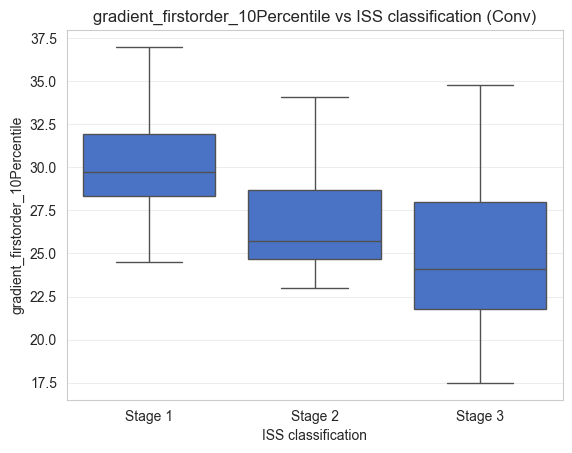

In [8]:
# BOXPLOT Visualizations
from helper_files.feature_selection_helper import *

clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
all_csvs = merged_lesions_csv(r"E:\DATA_Myelomy")

image_type = "konv"
merged_df = pd.merge(all_csvs[image_type], clinical_df, left_on='patient', right_on='Patient ID')

clinical_col = "ISS classification"
radiomic_col = "gradient_firstorder_10Percentile"  # original_firstorder_Skewness, original_firstorder_Kurtosis, original_glcm_MaximumProbability
# original_glcm_Idm

sns.set_style("whitegrid")
sns.boxplot(data=merged_df, x=clinical_col, y=radiomic_col, showfliers=False)
plt.title(f"{radiomic_col} vs {clinical_col} ({image_type})")


from scipy.stats import kruskal

groups = [group[radiomic_col].dropna() for name, group in merged_df.groupby(clinical_col)]
stat, p_value = kruskal(*groups)

print(f"--- Kruskal-Wallis Test pre {radiomic_col} ---")
print(f"Statistika: {stat:.4f}")
print(f"p-hodnota: {p_value:.8f}")

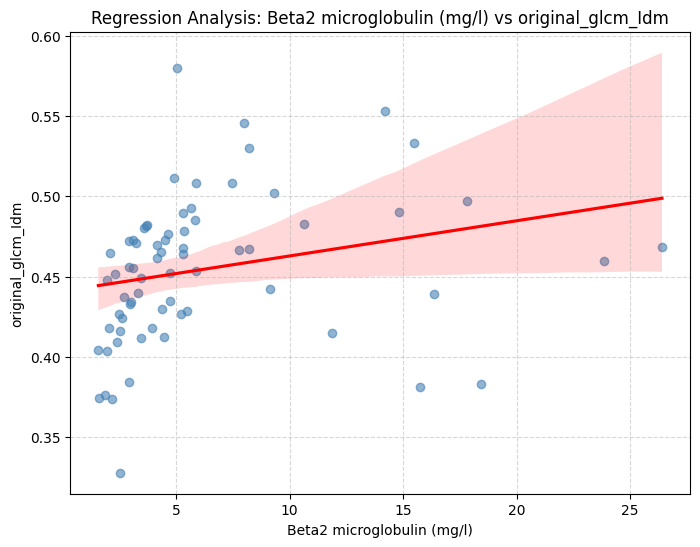

In [9]:
from helper_files.feature_selection_helper import *

clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
numeric_features_clinical = clinical_df.select_dtypes(include=['number']).columns

all_csvs = merged_lesions_csv(r"E:\DATA_Myelomy")
plt.style.use('default')

# --- NASTAVENIA VÝBERU ---
target_image_type = "monoe_40kev"
target_clinical = "Beta2 microglobulin (mg/l)"
target_radiomic = "original_glcm_Idm"
# -------------------------
# 1. Získanie konkrétneho datasetu
if target_image_type in all_csvs:
    radiomic_df = all_csvs[target_image_type]

    # 2. Merge s klinickými dátami
    merged_df = pd.merge(radiomic_df, clinical_df, left_on='patient', right_on='Patient ID')

    # Kontrola, či stĺpce existujú
    if target_radiomic in merged_df.columns and target_clinical in merged_df.columns:

        # Odstránenie NaN pre výpočet korelácie
        subset = merged_df[[target_radiomic, target_clinical]].dropna()

        if len(subset) > 1:
            corr, p_value = spearmanr(subset[target_radiomic], subset[target_clinical])

            # 3. Vykreslenie grafu
            plt.figure(figsize=(8, 6))
            sns.regplot(
                data=merged_df,
                x=target_clinical,
                y=target_radiomic,
                robust=True,
                scatter_kws={'alpha': 0.6, 'color': 'steelblue'},
                line_kws={'color': 'red'}
            )

            plt.title(f"Regression Analysis: {target_clinical} vs {target_radiomic}", fontsize=12)
            plt.xlabel(target_clinical)
            plt.ylabel(target_radiomic)
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.show()